In [1]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *
import pandas as pd
import os

from experiment_config import experiment_configuration
from utils import extract_schedule_cars, usage



In [2]:
import gurobipy as gp
from gurobipy import GRB
from gurobipy import *

def run_model(Operations, Ressources, predecessors, duration, q, variants):

    J= len(Operations)
    R= len(Ressources)
    V = len(variants)

    allowed_machines= {}

    for v in variants:
        for j in range(len(variants[v])):
            allowed_machines.update({(v,j): variants[v][j]})

    cars = [] # each car produced of each variant becomes it's own entity
    for v in variants.keys():
        for idx in range(q[v]):
            cars.append((v, idx))

    CARS = len(cars)
    type_of = {c: cars[c][0] for c in range(CARS)}
    sum_d = sum(duration[0])
    T = CARS * sum_d 
    

    FEZ = [0]*J
    SEZ = [T-1]*J

    m = gp.Model("RCPSP")

    # decision variables
    S = m.addVars(CARS, J, T, vtype= GRB.BINARY) # ==1 if job j starts for car c in time t
    Y = m.addVars(CARS, J, R, vtype=GRB.BINARY) # ==1 if job j is for car c on maschine r
    C = m.addVar(lb= 0, vtype= GRB.CONTINUOUS) # makespan

    # Objective
    m.setObjective(C, GRB.MINIMIZE)

    # Constraints

    # symbreak (cars are sorted depending on their starting timepoint)
    cars_by_v = {v: [c for c in range(CARS) if type_of[c] == v] for v in range(V)}

    for v in cars_by_v:
        cars_by_v[v].sort()

    j0 = 0
    for v, car_list in cars_by_v.items():
        for a, b in zip(car_list[:-1], car_list[1:]):
            m.addConstr(
                quicksum(t * S[a, j0, t] for t in range(FEZ[j0], SEZ[j0] + 1))
                <=
                quicksum(t * S[b, j0, t] for t in range(FEZ[j0], SEZ[j0] + 1)),
                name=f"sym_start_v{v}_c{a}_c{b}"
            )

    # time constraint
    for c in range(CARS):
        for j in range(J):
            m.addConstr(C >= sum((t + duration[type_of[c]][j]) * S[c,j,t] for t in range(FEZ[j], SEZ[j]+1)))

    # timeslot constraint
    # the job needs to be finished in a certain timeframe
    for c in range(CARS):
        for j in range(J):
            m.addConstr((quicksum(S[c, j, t] for t in range(FEZ[j], SEZ[j]+1)) == 1))

    # variant_based useable machines
    # variants are allowed to be produced on a predefined set of machines
    for c in range(CARS):
        v = type_of[c]
        for j in range(J):
            m.addConstr(quicksum(Y[c,j,r] for r in allowed_machines[(v,j)]) == 1)
            for r in range(R):
                if r not in allowed_machines[(v,j)]:
                    m.addConstr(Y[c,j,r] == 0)

    # precendence constraint
    # realise the order of the correct process
    for c in range(CARS):
        for j in range(J):
                for h in predecessors[j]:
                        m.addConstr(quicksum(t * S[c,h, t] for t in range(FEZ[h], SEZ[h]+1)) + duration[type_of[c]][h] <= quicksum(t * S[c,j, t] for t in range(FEZ[j], SEZ[j]+1)))

    # capacity constraint
    # the defined capacity needs to be kept
    for r in range(R):
        for t in range(T):
            m.addConstr((quicksum(Y[c,j,r] * quicksum(S[c,j,q] for q in range(max(FEZ[j], t - duration[type_of[c]][j] + 1), min(SEZ[j], t) + 1)) for c in range(CARS) for j in range(J)) <= 1))

    latest = {(c,j): min(SEZ[j], T - duration[type_of[c]][j]) for c in range(CARS) for j in range(J)}

    # ensuring that no job ende after the defined periods
    for c in range(CARS):
        for j in range(J):
            for t in range(T):
                if t < FEZ[j] or t > latest[(c,j)]:
                    m.addConstr(S[c,j,t] == 0)

    # each variant can only be at a machine at the same time
    for c in range(CARS):
        for t in range(T):
            m.addConstr(gp.quicksum(gp.quicksum(S[c,j,q] for q in range(max(FEZ[j], t - duration[type_of[c]][j] + 1), min(latest[(c,j)], t) + 1)) for j in range(J)) <= 1)

    m.setParam("TimeLimit", 1800)  # 30 minutes
    m.setParam("MIPGap", 0.01) 
    # m.setParam("MIPFocus", 2)

    # Solve
    m.optimize()

    if m.SolCount == 0:
        return None, None, None, None, m.Status, m.Runtime, None

    makespan = C.X

    total_work_content = 0
    for variant in q.keys():
        for job in range(len(Operations)):
            total_work_content += duration[variant][job] * q[variant]

    schedule = extract_schedule_cars(S, Y, duration, type_of, CARS, J, R, T, eps=0.5)
    machine_usage, downtime_per_machine, downtime_over_makespan = usage(schedule, makespan)

    gap = m.MIPGap if m.Status in [GRB.OPTIMAL, GRB.TIME_LIMIT] else None
    return makespan, downtime_per_machine, downtime_over_makespan, machine_usage, total_work_content, m.Status, m.Runtime, gap, m, S, Y, CARS, J, R, T, type_of, C

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

def extract_schedule_cars_diagram(S, Y, duration, CARS, J, R, T, eps=0.5):
    """
    Returns list of (machine, start, dur, car, job).
    """
    # start time per (c,j)
    start = {}
    for (c, j, t), var in S.items():
        if var.X > eps:
            start[(c, j)] = t

    # machine per (c,j)
    mach = {}
    for (c, j, r), var in Y.items():
        if var.X > eps:
            mach[(c, j)] = r

    sched = []
    for c in range(CARS):
        for j in range(J):
            sched.append((mach[(c, j)], start[(c, j)], duration[type_of[c]][j], c, j))
    return sched

def plot_gantt_per_machine_cars(schedule, type_of, makespan=None, T=None,
                                title="Gantt per machine",
                                show_labels=False):
    """
    schedule: list (r, start, dur, c, j)
    type_of: dict car -> variant
    """
    if makespan is None:
        makespan = max(s + d for r, s, d, c, j in schedule)
    if T is None:
        T = makespan

    machines = sorted({r for r, *_ in schedule})
    y_pos = {r: i for i, r in enumerate(machines)}

    # colors by variant
    variants = sorted({type_of[c] for _, _, _, c, _ in schedule})
    cmap = plt.get_cmap("tab10")
    v_color = {v: cmap(i % 10) for i, v in enumerate(variants)}

    # group segments per machine+variant for faster plotting
    segs = defaultdict(list)   # (r, v) -> [(start, dur), ...]
    texts = defaultdict(list)  # r -> [(x, y, label), ...]

    for r, start, dur, c, j in schedule:
        v = type_of[c]
        segs[(r, v)].append((start, dur))
        if show_labels:
            texts[r].append((start + dur/2, y_pos[r], f"c{c}-j{j}"))

    fig, ax = plt.subplots(figsize=(14, 0.8*len(machines) + 2))

    for r in machines:
        y = y_pos[r]
        for v in variants:
            if (r, v) in segs:
                ax.broken_barh(segs[(r, v)], (y-0.4, 0.8),
                               edgecolors="black", linewidth=0.5,
                               facecolors=v_color[v])

        if show_labels:
            for x, yy, lab in texts[r]:
                ax.text(x, yy, lab, ha="center", va="center", fontsize=6)

    ax.set_yticks([y_pos[r] for r in machines])
    ax.set_yticklabels([f"M{r}" for r in machines])
    ax.set_xlim(0, makespan + 3)
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.4)

    ax.axvline(makespan, linestyle="--")
    ax.text(makespan, len(machines)-0.5, f"  C={makespan:.0f}", va="bottom")

    handles = [plt.Rectangle((0,0), 1, 1, color=v_color[v]) for v in variants]
    ax.legend(handles, [f"Variant {v}" for v in variants],
              loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()

def plot_gantt_per_car(schedule, type_of, makespan=None, T=None,
                       title="Gantt per car (each car is one row)",
                       show_labels=False, max_cars_to_label=25):
    """
    schedule: list (r, start, dur, c, j)
    """
    if makespan is None:
        makespan = max(s + d for r, s, d, c, j in schedule)
    if T is None:
        T = makespan

    cars = sorted({c for _, _, _, c, _ in schedule})
    y_pos = {c: i for i, c in enumerate(cars)}

    machines = sorted({r for r, *_ in schedule})
    cmap = plt.get_cmap("tab20")  # more colors
    r_color = {r: cmap(i % 20) for i, r in enumerate(machines)}

    # group by car+machine
    segs = defaultdict(list)  # (c, r) -> [(start, dur)]
    texts = []

    for r, start, dur, c, j in schedule:
        segs[(c, r)].append((start, dur))
        if show_labels and len(cars) <= max_cars_to_label:
            texts.append((start + dur/2, y_pos[c], f"j{j}"))

    fig, ax = plt.subplots(figsize=(14, 0.25*len(cars) + 2))

    for c in cars:
        y = y_pos[c]
        for r in machines:
            if (c, r) in segs:
                ax.broken_barh(segs[(c, r)], (y-0.4, 0.8),
                               edgecolors="black", linewidth=0.4,
                               facecolors=r_color[r])

    if show_labels and len(cars) <= max_cars_to_label:
        for x, y, lab in texts:
            ax.text(x, y, lab, ha="center", va="center", fontsize=6)

    ax.set_yticks([y_pos[c] for c in cars])
    # label as cX (vY) to show variant
    ax.set_yticklabels([f"c{c} (v{type_of[c]})" for c in cars])
    ax.set_xlim(0, makespan + 3)
    ax.set_xlabel("time")
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.4)

    ax.axvline(makespan, linestyle="--")
    ax.text(makespan, len(cars)-0.5, f"  C={makespan:.0f}", va="bottom")

    handles = [plt.Rectangle((0,0), 1, 1, color=r_color[r]) for r in machines]
    ax.legend(handles, [f"M{r}" for r in machines],
              loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()


In [4]:
variant = experiment_configuration["Experiment 1"]["4 Layers"]
Operations = variant["Operations"]
Ressources = variant["Ressources"]
predecessors = variant["predecessors"]
duration = variant["duration"]
q = variant["q"]
variants = variant["variants"]
makespan, downtime_per_machine, downtime_over_makespan, usage, total_work_content, status, runtime, gap, m, S, Y, CARS, J, R, T, type_of, C = run_model(Operations, Ressources, predecessors, duration, q, variants)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2726523
Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Set parameter TimeLimit to value 1800
Set parameter MIPGap to value 0.01
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  1800
MIPGap  0.01

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 10167 rows, 33841 columns and 177876 nonzeros
Model fingerprint: 0x97173134
Model has 1440 quadratic constraints
Variable types: 1 continuous, 33840 integer (33840 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+02]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     

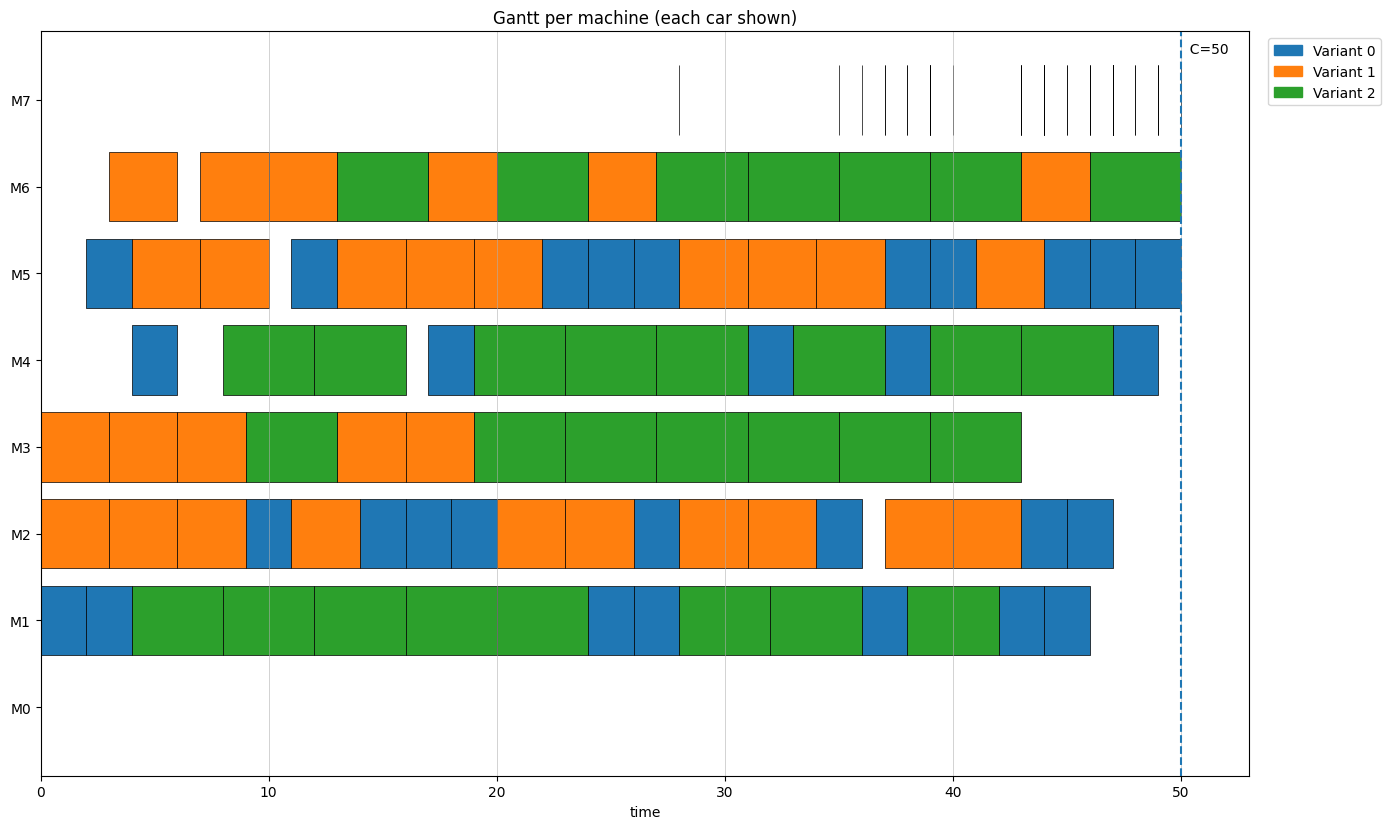

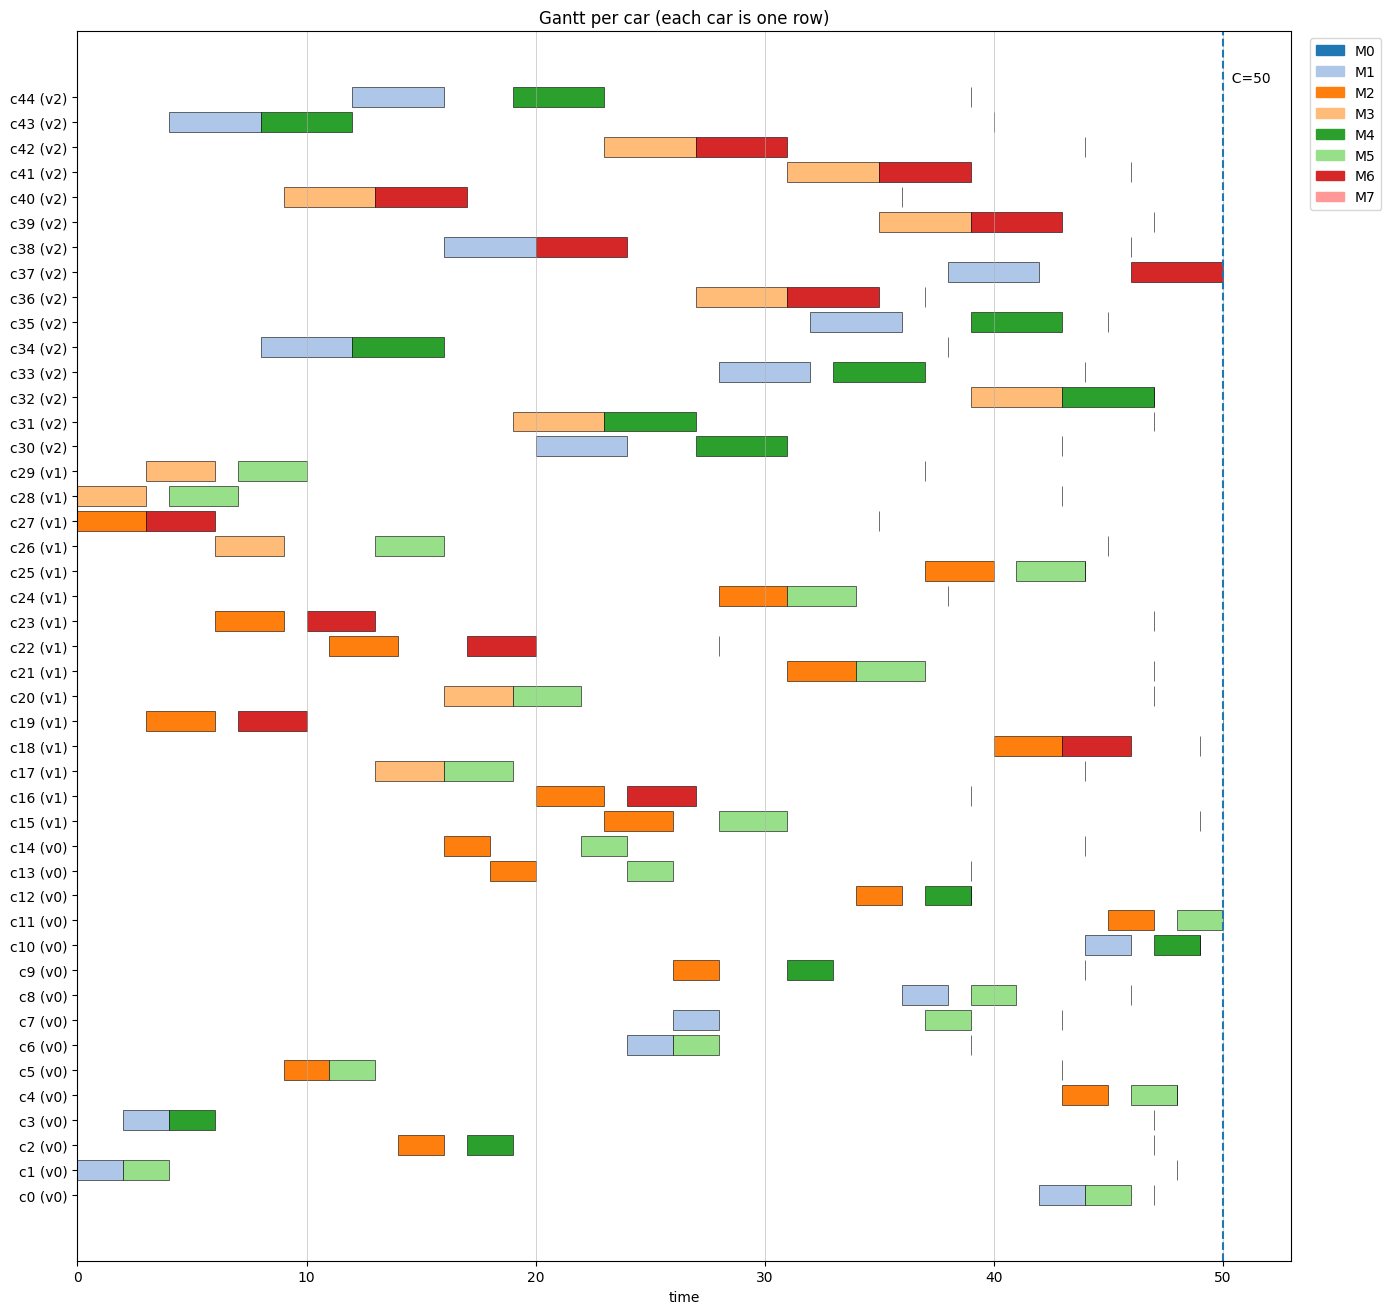

In [7]:
S, Y, CARS, J, R, T, type_of, C

schedule = extract_schedule_cars_diagram(S, Y, duration, CARS, J, R, T, eps=0.5)

# Plot 1: per machine
plot_gantt_per_machine_cars(schedule, type_of, makespan=C.X, T=T, show_labels=False)

# Plot 2: per car
plot_gantt_per_car(schedule, type_of, makespan=C.X, T=T, show_labels=False)

# if m.status == GRB.OPTIMAL:
#     schedule = extract_schedule_cars_diagram(S, Y, duration, CARS, J, R, T, eps=0.5)

#     # Plot 1: per machine
#     plot_gantt_per_machine_cars(schedule, type_of, makespan=C.X, T=T, show_labels=False)

#     # Plot 2: per car
#     plot_gantt_per_car(schedule, type_of, makespan=C.X, T=T, show_labels=False)
# else:
#     print("No optimal solution:", m.status)


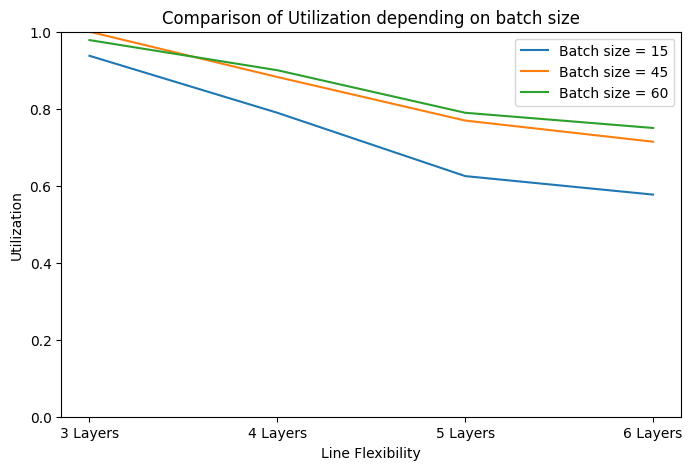

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

df = pd.read_csv("data/experiment_results_backup_9.csv")
cols_to_parse = ["usage", "active_usage", "downtime_per_machine", "downtime_over_makespan"]

for col in cols_to_parse:
    df[col] = df[col].apply(lambda s: ast.literal_eval(s) if isinstance(s, str) else s)
df = df[df["experiment"].isin(["Experiment 1", "Experiment 6", "Experiment 7"])]
fig = plt.figure(figsize=(8,5))

for experiment in pd.unique(df["experiment"]):
    df_experiment = df[df["experiment"]==experiment]#
    if experiment=="Experiment 1":
        label = "Batch size = 15"  
    elif experiment=="Experiment 6":
        label = "Batch size = 45"    
    else:
        label = "Batch size = 60"         
    y = df_experiment["usage"]

    avg_util = []
    for variant in y:
        util_sum = 0
        counter = 0
        for index, u in enumerate(variant): 
            if index == 0 or index == len(variant)-1:
                continue
            util_sum += u[2]
            counter +=1
        avg_util.append(util_sum / counter)


    x = df_experiment["experiment_version"]
    plt.plot(x, avg_util, label=label)
plt.ylabel("Utilization")
plt.xlabel("Line Flexibility")
plt.ylim(0,1)
plt.title("Comparison of Utilization depending on batch size")
plt.legend()
plt.show()

In [6]:
data = pd.read_csv("experiment_results_2.csv", index_col=0)

df = data[data["experiment"]=="Experiment 4"] 

makespan = pd.Series(df["makespan"]).reset_index(drop=True)
TWC = pd.Series(df["total_work_content"]).reset_index(drop=True)

first_value = 1
second_value = 0

print((makespan[first_value] - makespan[second_value])/makespan[second_value])

print((TWC[first_value] - TWC[second_value])/TWC[second_value])

FileNotFoundError: [Errno 2] No such file or directory: 'experiment_results_2.csv'

In [ ]:
import numpy as np
E = []

TWC_arr = np.asarray(TWC, dtype=float)
C_arr   = np.asarray(makespan, dtype=float)

for i in range(1, len(TWC_arr)):
    dW = (TWC_arr[i] - TWC_arr[i-1]) / TWC_arr[i-1]
    dC = (C_arr[i] - C_arr[i-1]) / C_arr[i-1]
    E.append(dC / dW)

avg_E = np.array(E).sum() / len(E)
print(avg_E)

0.7666666666666666
